In [1]:


import pandas as pd
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor

# 1. Load the data
df = pd.read_excel(r"C:\Users\PRIYDARSHINI\Documents\normalized_data_final.xlsx")

# 2. Define pillars
e_cols = ['GHG Emission Intensity', 'Water Intensity', 'Energy Consumption', 'Energy Intensity', 'Waste Generated']
s_cols = ['Female Representation', 'Average Training Hours', 'Worker LTIFR', 'CSR Expenditure', 'Female Representation2']
g_cols = ['Independent Directors']

# 3. Calculate Pillar scores (averages)
df['E_Score'] = df[e_cols].mean(axis=1)
df['S_Score'] = df[s_cols].mean(axis=1)
df['G_Score'] = df[g_cols].mean(axis=1)

# 4. Calculate Sustainability Index (Equal Weights)
df['Sustainability_Index'] = (df['E_Score'] + df['S_Score'] + df['G_Score']) / 3

# 5. AI/ML: K-Means Clustering for categorization
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
df['Cluster'] = kmeans.fit_predict(df[['Sustainability_Index']])
# Map clusters to meaningful names
cluster_map = {0: 'Leader', 1: 'Moderate', 2: 'Laggard'}
df['Performance_Category'] = df['Cluster'].map(cluster_map)

# 6. AI/ML: Random Forest for Feature Importance (ESG Drivers)
X = df[e_cols + s_cols + g_cols]
y = df['Sustainability_Index']
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)
importances = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_}).sort_values(by='Importance', ascending=False)

# 7. Final Company Ranking (Averaged over years)
final_ranking = df.groupby('COMPANY')['Sustainability_Index'].mean().reset_index()
final_ranking['Rank'] = final_ranking['Sustainability_Index'].rank(ascending=False)
final_ranking = final_ranking.sort_values(by='Rank')

# Display results
print("--- Final Company Rankings ---")
print(final_ranking[['COMPANY', 'Sustainability_Index', 'Rank']].to_string(index=False))
print("\n--- AI Model Performance (Clusters) ---")
print(df[['COMPANY', 'YEAR', 'Sustainability_Index', 'Performance_Category']].to_string(index=False))
print("\n--- Feature Importance (ESG Drivers) ---")
print(importances.to_string(index=False))

C:\Users\PRIYDARSHINI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


--- Final Company Rankings ---
                        COMPANY  Sustainability_Index  Rank
POWER GRID CORPORATION OF INDIA              0.629369   1.0
                   NTPC LIMITED              0.440845   2.0
                    ADANI POWER              0.399110   3.0

--- AI Model Performance (Clusters) ---
                        COMPANY     YEAR  Sustainability_Index Performance_Category
                    ADANI POWER FY 24-25              0.417048             Moderate
                    ADANI POWER FY 23-24              0.348629              Laggard
                    ADANI POWER FY 22-23              0.431654             Moderate
POWER GRID CORPORATION OF INDIA FY 24-25              0.596205               Leader
POWER GRID CORPORATION OF INDIA FY 23-24              0.663234               Leader
POWER GRID CORPORATION OF INDIA FY 22-23              0.628668               Leader
                   NTPC LIMITED FY 24-25              0.455200             Moderate
                

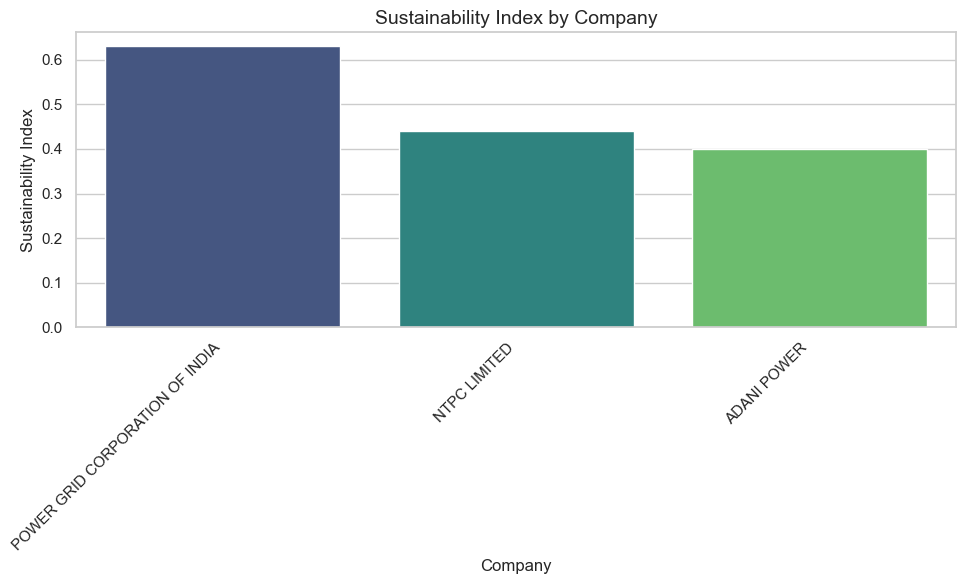

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_theme(style="whitegrid")

# Create the figure
plt.figure(figsize=(10, 6))

# Plot the ranking
sns.barplot(data=final_ranking, x='COMPANY', y='Sustainability_Index', palette='viridis',hue='COMPANY',legend=False)

# Customizing the plot
plt.title('Sustainability Index by Company', fontsize=14)
plt.ylabel('Sustainability Index', fontsize=12)
plt.xlabel('Company', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Display the chart
plt.show()

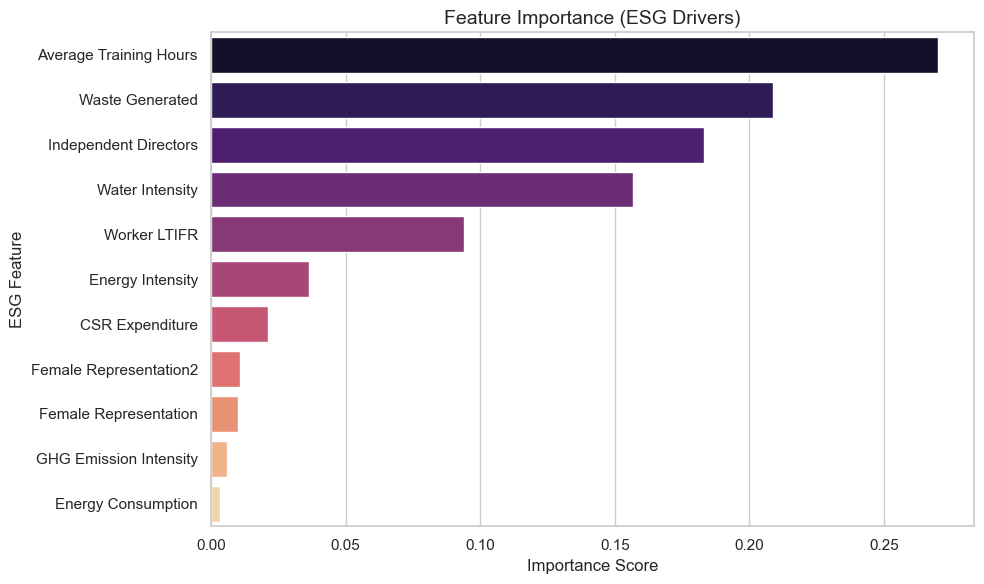

In [5]:
# Create the figure
plt.figure(figsize=(10, 6))
import pandas as pd

# This creates the variable 'importance_df' so the plot code can find it
feature_data = {
    'Feature': ['Average Training Hours', 'Waste Generated', 'Independent Directors', 'Water Intensity', 'Worker LTIFR', 'Energy Intensity', 'CSR Expenditure', 'Female Representation2', 'Female Representation', 'GHG Emission Intensity', 'Energy Consumption'],
    'Importance': [0.269916, 0.208587, 0.182958, 0.156862, 0.093986, 0.036464, 0.021136, 0.010712, 0.010061, 0.005965, 0.003352]
}
importance_df = pd.DataFrame(feature_data)


# Plot feature importance (horizontal bar)
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma',hue='Feature',legend=False)

# Customizing the plot
plt.title('Feature Importance (ESG Drivers)', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('ESG Feature', fontsize=12)
plt.tight_layout()

# Display the chart
plt.show()